### Week 7 Assignment: ARIA v4.0 (The Accessible Auditor)

#### Step1：Environment Setup & Global Configuration

In [29]:
# ============================================================
# Cell 1 — Environment Setup & Global Configuration
# ARIA v4.0 / Homework-Week7
# ============================================================

# 如果你還沒安裝套件，先取消下面註解執行一次
# !pip install osmnx geopandas rasterio networkx python-dotenv shapely matplotlib pandas numpy

import os
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import rasterio

from shapely.geometry import Point, LineString, MultiPoint
from shapely.ops import unary_union

# -----------------------------
# 1. Define project folders
# -----------------------------
# 目前 notebook 位於 HW7/scripts
# 因此專案根目錄是上一層 HW7
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
ENV_PATH = PROJECT_ROOT / ".env"

# 建立輸出資料夾（若不存在）
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# 2. Load .env
# -----------------------------
if not ENV_PATH.exists():
    raise FileNotFoundError(f".env file not found: {ENV_PATH}")

load_dotenv(dotenv_path=ENV_PATH, override=True)

# -----------------------------
# 3. Read environment variables
# -----------------------------
NETWORK_DIST = int(os.getenv("NETWORK_DIST", 5000))
NETWORK_CRS = os.getenv("NETWORK_CRS", "EPSG:3826")
CONGESTION_METHOD = os.getenv("CONGESTION_METHOD", "threshold")

CONGESTION_BREAK_1 = float(os.getenv("CONGESTION_BREAK_1", 10))
CONGESTION_BREAK_2 = float(os.getenv("CONGESTION_BREAK_2", 40))
CONGESTION_BREAK_3 = float(os.getenv("CONGESTION_BREAK_3", 80))

# Homework-Week7 主要要求 5 與 10 分鐘，先預設為 5,10
ISOCHRONE_MINUTES = [
    int(x.strip()) for x in os.getenv("ISOCHRONE_MINUTES", "5,10").split(",")
]
ALPHA_SHAPE_ALPHA = float(os.getenv("ALPHA_SHAPE_ALPHA", 0.001))

# -----------------------------
# 4. Define input file paths
# -----------------------------
# 雨量資料：若有 kriging_rainfall.tif 就走 raster 路線；沒有也可後續改用 W5 JSON
KRIGING_RAINFALL_PATH = Path(
    os.getenv("KRIGING_RAINFALL_PATH", str(DATA_DIR / "kriging_rainfall.tif"))
)

# Shelter：請確認你的實際檔名是否為 shelter_with_risk.geojson 或 shelters_with_risk.geojson
SHELTER_GEODATAFRAME_PATH = Path(
    os.getenv("SHELTER_GEODATAFRAME_PATH", str(DATA_DIR / "shelter_with_risk.geojson"))
)

# Terrain risk：你目前手上是 GeoJSON，不是 tif
TERRAIN_RISK_GEOJSON_PATH = Path(
    os.getenv("TERRAIN_RISK_GEOJSON_PATH", str(DATA_DIR / "terrain_risk_audit.geojson"))
)

# 如果你後續真的轉成 raster，再另外用這個變數
TERRAIN_RISK_TIF_PATH = Path(
    os.getenv("TERRAIN_RISK_TIF_PATH", str(DATA_DIR / "terrain_risk.tif"))
)

# -----------------------------
# 5. Basic plotting / osmnx settings
# -----------------------------
ox.settings.use_cache = True
ox.settings.log_console = False
plt.rcParams["figure.figsize"] = (10, 10)

# -----------------------------
# 6. Check file existence
# -----------------------------
print("✅ Environment setup complete")
print(f"Working directory              : {Path.cwd()}")
print(f"Project root                   : {PROJECT_ROOT}")
print(f"Data directory                 : {DATA_DIR}")
print(f"Output directory               : {OUTPUT_DIR}")
print(f".env path                      : {ENV_PATH}")
print()
print(f"NETWORK_DIST                   : {NETWORK_DIST}")
print(f"NETWORK_CRS                    : {NETWORK_CRS}")
print(f"CONGESTION_METHOD              : {CONGESTION_METHOD}")
print(f"CONGESTION_BREAKS              : {CONGESTION_BREAK_1}, {CONGESTION_BREAK_2}, {CONGESTION_BREAK_3}")
print(f"ISOCHRONE_MINUTES              : {ISOCHRONE_MINUTES}")
print(f"ALPHA_SHAPE_ALPHA              : {ALPHA_SHAPE_ALPHA}")
print()
print(f"KRIGING_RAINFALL_PATH          : {KRIGING_RAINFALL_PATH}")
print(f"KRIGING file exists?           : {KRIGING_RAINFALL_PATH.exists()}")
print()
print(f"SHELTER_GEODATAFRAME_PATH      : {SHELTER_GEODATAFRAME_PATH}")
print(f"Shelter file exists?           : {SHELTER_GEODATAFRAME_PATH.exists()}")
print()
print(f"TERRAIN_RISK_GEOJSON_PATH      : {TERRAIN_RISK_GEOJSON_PATH}")
print(f"Terrain GeoJSON exists?        : {TERRAIN_RISK_GEOJSON_PATH.exists()}")
print()
print(f"TERRAIN_RISK_TIF_PATH          : {TERRAIN_RISK_TIF_PATH}")
print(f"Terrain TIFF exists?           : {TERRAIN_RISK_TIF_PATH.exists()}")

✅ Environment setup complete
Working directory              : c:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\scripts
Project root                   : C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7
Data directory                 : C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\data
Output directory               : C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output
.env path                      : C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\.env

NETWORK_DIST                   : 5000
NETWORK_CRS                    : EPSG:3826
CONGESTION_METHOD              : threshold
CONGESTION_BREAKS              : 10.0, 40.0, 80.0
ISOCHRONE_MINUTES              : [5, 10]
ALPHA_SHAPE_ALPHA              : 0.001

KRIGING_RAINFALL_PATH          : ..\data\kriging_rainfall.tif
KRIGING file exists?           : True

SHELTER_GEODATAFRAME_PATH      : ..\data\shelters_with

#### step2：Load and Inspect Terrain Risk GeoJSON

In [8]:
# ============================================================
# Cell 2 — Load and Inspect Terrain Risk GeoJSON
# ============================================================

terrain_gdf = gpd.read_file(TERRAIN_RISK_GEOJSON_PATH)

print("✅ terrain_risk_audit.geojson loaded")
print("\n--- Basic Info ---")
print("CRS:", terrain_gdf.crs)
print("Shape:", terrain_gdf.shape)

print("\n--- Columns ---")
print(list(terrain_gdf.columns))

print("\n--- Geometry Types ---")
print(terrain_gdf.geom_type.value_counts())

print("\n--- First 5 Rows ---")
display(terrain_gdf.head())

✅ terrain_risk_audit.geojson loaded

--- Basic Info ---
CRS: EPSG:3826
Shape: (198, 25)

--- Columns ---
['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置', 'TWD97_lon', 'TWD97_lat', 'is_indoor', 'mean_elevation', 'max_slope', 'std_elevation', 'river_distance_m', 'river_distance_category', 'risk_level', 'geometry']

--- Geometry Types ---
Point    198
Name: count, dtype: int64

--- First 5 Rows ---


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,TWD97_lon,TWD97_lat,is_indoor,mean_elevation,max_slope,std_elevation,river_distance_m,river_distance_category,risk_level,geometry
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,326011.110652,2.689347e+06,True,27.502351,45.473251,17.994240,865.673162,500-1000公尺之間,高風險,POINT (326011.111 2689346.508)
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,277505.778883,2.560143e+06,True,299.459149,41.046368,13.260633,53.524272,小於500公尺,極高風險,POINT (277505.779 2560143.417)
2,1332,花蓮縣富里鄉,富南村,富南村4鄰42-1號,121.239900,23.161200,玉寶宮,富南村,20,"水災,土石流",...,274563.446701,2.562154e+06,True,240.630908,29.891891,7.838210,277.175989,小於500公尺,高風險,POINT (274563.447 2562153.682)
3,1342,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,121.256500,23.171400,永豐社區活動中心,永豐村,50,"水災,土石流",...,276261.145008,2.563286e+06,True,257.456815,32.286247,22.753039,342.785916,小於500公尺,極高風險,POINT (276261.145 2563286.086)
4,1350,花蓮縣富里鄉,富里村,中山路205號,121.247624,23.174527,富里老人文康中心,富里村,100,"水災,土石流",...,275351.803863,2.563631e+06,True,238.324347,30.526333,18.284005,294.440576,小於500公尺,極高風險,POINT (275351.804 2563630.784)


#### step3：Standardize Shelter / Facility GeoDataFrame

In [9]:
# ============================================================
# Cell 3 — Standardize Shelter / Facility GeoDataFrame
# ============================================================

# 1. 複製一份，避免直接改原始 terrain_gdf
shelter_gdf = terrain_gdf.copy()

# 2. 統一欄位名稱（建立後續分析用的標準欄位）
# 設施名稱
if "避難收容處所名稱" in shelter_gdf.columns:
    shelter_gdf["facility_name"] = shelter_gdf["避難收容處所名稱"]
else:
    shelter_gdf["facility_name"] = shelter_gdf.index.astype(str)

# 行政區
if "縣市及鄉鎮市區" in shelter_gdf.columns:
    shelter_gdf["admin_area"] = shelter_gdf["縣市及鄉鎮市區"]
else:
    shelter_gdf["admin_area"] = None

# 風險等級
if "risk_level" in shelter_gdf.columns:
    shelter_gdf["facility_risk_level"] = shelter_gdf["risk_level"]
else:
    shelter_gdf["facility_risk_level"] = None

# 預計收容人數（如果存在）
if "預計收容人數" in shelter_gdf.columns:
    shelter_gdf["capacity"] = pd.to_numeric(shelter_gdf["預計收容人數"], errors="coerce")
else:
    shelter_gdf["capacity"] = np.nan

# 坡度
if "max_slope" in shelter_gdf.columns:
    shelter_gdf["facility_max_slope"] = pd.to_numeric(shelter_gdf["max_slope"], errors="coerce")
else:
    shelter_gdf["facility_max_slope"] = np.nan

# 高程
if "mean_elevation" in shelter_gdf.columns:
    shelter_gdf["facility_mean_elevation"] = pd.to_numeric(shelter_gdf["mean_elevation"], errors="coerce")
else:
    shelter_gdf["facility_mean_elevation"] = np.nan

# 河川距離
if "river_distance_m" in shelter_gdf.columns:
    shelter_gdf["facility_river_distance_m"] = pd.to_numeric(shelter_gdf["river_distance_m"], errors="coerce")
else:
    shelter_gdf["facility_river_distance_m"] = np.nan

# 3. 僅保留幾個後面分析會用到的重要欄位
keep_cols = [
    "facility_name",
    "admin_area",
    "facility_risk_level",
    "capacity",
    "facility_max_slope",
    "facility_mean_elevation",
    "facility_river_distance_m",
    "geometry"
]

shelter_gdf = shelter_gdf[keep_cols].copy()

# 4. 基本檢查
print("✅ shelter_gdf standardized")
print("CRS:", shelter_gdf.crs)
print("Shape:", shelter_gdf.shape)

print("\n--- Missing Values ---")
print(shelter_gdf.isna().sum())

print("\n--- Sample Records ---")
display(shelter_gdf.head())

print("\n--- Risk Level Distribution ---")
if shelter_gdf["facility_risk_level"].notna().sum() > 0:
    print(shelter_gdf["facility_risk_level"].value_counts(dropna=False))
else:
    print("No facility_risk_level values found.")

✅ shelter_gdf standardized
CRS: EPSG:3826
Shape: (198, 8)

--- Missing Values ---
facility_name                0
admin_area                   0
facility_risk_level          0
capacity                     0
facility_max_slope           0
facility_mean_elevation      0
facility_river_distance_m    0
geometry                     0
dtype: int64

--- Sample Records ---


,facility_name,admin_area,facility_risk_level,capacity,facility_max_slope,facility_mean_elevation,facility_river_distance_m,geometry
0,和平國小,花蓮縣秀林鄉,高風險,250,45.473251,27.502351,865.673162,POINT (326011.111 2689346.508)
1,豐南社區活動中心,花蓮縣富里鄉,極高風險,50,41.046368,299.459149,53.524272,POINT (277505.779 2560143.417)
2,玉寶宮,花蓮縣富里鄉,高風險,20,29.891891,240.630908,277.175989,POINT (274563.447 2562153.682)
3,永豐社區活動中心,花蓮縣富里鄉,極高風險,50,32.286247,257.456815,342.785916,POINT (276261.145 2563286.086)
4,富里老人文康中心,花蓮縣富里鄉,極高風險,100,30.526333,238.324347,294.440576,POINT (275351.804 2563630.784)



--- Risk Level Distribution ---
facility_risk_level
高風險     71
極高風險    53
低風險     52
中風險     22
Name: count, dtype: int64


#### step 4 ：Select 5 Key Facilities for Homework-Week7

In [10]:
# ============================================================
# Cell 4 — Select 5 Manually Chosen Nearby Facilities in Hualien City
# ============================================================

# 1. 建立風險排序分數（數字越大代表風險越高）
risk_rank_map = {
    "低風險": 1,
    "中風險": 2,
    "高風險": 3,
    "極高風險": 4
}

selected_base_gdf = shelter_gdf.copy()
selected_base_gdf["risk_rank"] = selected_base_gdf["facility_risk_level"].map(risk_rank_map)

# 2. 先限制在花蓮市
target_admin_area = "花蓮縣花蓮市"
candidate_gdf = selected_base_gdf[
    selected_base_gdf["admin_area"] == target_admin_area
].copy()

print(f"✅ Candidate facilities filtered by admin area: {target_admin_area}")
print(f"Total facilities in {target_admin_area}: {len(candidate_gdf)}")

# 3. 手動指定你想選的 5 個設施名稱
target_facility_names = [
    "中正國小",
    "中原國小文中三國中預定地",
    "忠孝國小",
    "主權社區活動中心",
    "國風國中"
]

print("\n--- Target facility names ---")
for name in target_facility_names:
    print("-", name)

# 4. 篩選這 5 個設施
selected_facilities_gdf = candidate_gdf[
    candidate_gdf["facility_name"].isin(target_facility_names)
].copy()

# 5. 檢查是否成功找到 5 個
found_names = selected_facilities_gdf["facility_name"].tolist()
missing_names = [name for name in target_facility_names if name not in found_names]

if len(selected_facilities_gdf) != 5:
    print("\n⚠️ Warning: not all 5 facilities were found.")
    print("Found facilities:")
    for name in found_names:
        print("-", name)

    print("\nMissing facilities:")
    for name in missing_names:
        print("-", name)

    raise ValueError(
        f"Expected 5 facilities, but found {len(selected_facilities_gdf)}. "
        "Please check whether the facility names exactly match the source data."
    )

# 6. 按你指定的順序排序
selected_facilities_gdf["facility_name"] = pd.Categorical(
    selected_facilities_gdf["facility_name"],
    categories=target_facility_names,
    ordered=True
)
selected_facilities_gdf = selected_facilities_gdf.sort_values("facility_name").reset_index(drop=True)

# 7. 建立 facility_id
selected_facilities_gdf["facility_id"] = [
    f"F{i+1}" for i in range(len(selected_facilities_gdf))
]

# 8. 調整欄位順序
selected_facilities_gdf = selected_facilities_gdf[
    [
        "facility_id",
        "facility_name",
        "admin_area",
        "facility_risk_level",
        "risk_rank",
        "capacity",
        "facility_max_slope",
        "facility_mean_elevation",
        "facility_river_distance_m",
        "geometry"
    ]
].copy()

print("\n✅ 5 manually selected facilities prepared")
print("Selection rule: manually selected nearby facilities in Hualien City")

display(selected_facilities_gdf)

print("\n--- Selected Risk Level Summary ---")
print(selected_facilities_gdf["facility_risk_level"].value_counts())

print("\n--- Selected Capacity Summary ---")
print(selected_facilities_gdf["capacity"].describe())

print("\n--- Selected Admin Area ---")
print(selected_facilities_gdf["admin_area"].value_counts())

✅ Candidate facilities filtered by admin area: 花蓮縣花蓮市
Total facilities in 花蓮縣花蓮市: 28

--- Target facility names ---
- 中正國小
- 中原國小文中三國中預定地
- 忠孝國小
- 主權社區活動中心
- 國風國中

✅ 5 manually selected facilities prepared
Selection rule: manually selected nearby facilities in Hualien City


,facility_id,facility_name,admin_area,facility_risk_level,risk_rank,capacity,facility_max_slope,facility_mean_elevation,facility_river_distance_m,geometry
0,F1,中正國小,花蓮縣花蓮市,中風險,2,187,5.644842,10.053611,595.583380,POINT (311028.524 2652018.751)
1,F2,中原國小文中三國中預定地,花蓮縣花蓮市,高風險,3,85,11.269644,12.500920,377.323611,POINT (310692.644 2652028.402)
2,F3,忠孝國小,花蓮縣花蓮市,中風險,2,47,5.381811,10.996952,838.731340,POINT (310914.746 2652450.204)
3,F4,主權社區活動中心,花蓮縣花蓮市,中風險,2,72,7.493312,14.705003,513.634492,POINT (310426.23 2652459.213)
4,F5,國風國中,花蓮縣花蓮市,中風險,2,800,6.076158,13.419985,850.295062,POINT (310587.744 2652770.002)



--- Selected Risk Level Summary ---
facility_risk_level
中風險    4
高風險    1
Name: count, dtype: int64

--- Selected Capacity Summary ---
count      5.000000
mean     238.200000
std      318.547799
min       47.000000
25%       72.000000
50%       85.000000
75%      187.000000
max      800.000000
Name: capacity, dtype: float64

--- Selected Admin Area ---
admin_area
花蓮縣花蓮市    5
Name: count, dtype: int64


#### step 5 ：Fetch Road Network Covering the 5 Selected Facilities

In [11]:
# ============================================================
# Cell 5 — Fetch / Load Road Network Covering the 5 Selected Facilities
# Fast version for nearby facilities in Hualien City
# ============================================================
from pathlib import Path
import osmnx as ox


GRAPHML_PATH = Path("../output/hualien_network.graphml")

# ------------------------------------------------------------
# 0. If GraphML already exists, load it directly
# ------------------------------------------------------------
if GRAPHML_PATH.exists():
    print(f"✅ Found existing GraphML: {GRAPHML_PATH}")
    G_proj = ox.load_graphml(GRAPHML_PATH)
    print("✅ Road network loaded from GraphML")
    print(f"Projected graph - nodes: {G_proj.number_of_nodes()}, edges: {G_proj.number_of_edges()}")
    print(f"Projected CRS: {G_proj.graph['crs']}")

else:
    # --------------------------------------------------------
    # 1. Convert facility points to WGS84 for OSMnx bbox
    # --------------------------------------------------------
    selected_facilities_wgs84 = selected_facilities_gdf.to_crs(epsg=4326)

    # --------------------------------------------------------
    # 2. Compute bounding box
    # --------------------------------------------------------
    minx, miny, maxx, maxy = selected_facilities_wgs84.total_bounds

    # 這組設施彼此很近，buffer 不需要太大
    # 0.001 度約略是百公尺等級外擴，通常夠用
    bbox_buffer = 0.001

    west = minx - bbox_buffer
    south = miny - bbox_buffer
    east = maxx + bbox_buffer
    north = maxy + bbox_buffer

    print("✅ Selected facility bounding box prepared")
    print(f"west  = {west}")
    print(f"south = {south}")
    print(f"east  = {east}")
    print(f"north = {north}")
    print(f"bbox_buffer = {bbox_buffer}")

    # --------------------------------------------------------
    # 3. Download drive road network from OSM
    # --------------------------------------------------------
    print("⏳ Downloading road network from OSM...")

    G = ox.graph_from_bbox(
        (north, south, east, west),
        network_type="drive",
        simplify=True
    )

    print("✅ Road network downloaded from OSM")
    print(f"Original graph - nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

    # --------------------------------------------------------
    # 4. Project to homework CRS
    # --------------------------------------------------------
    G_proj = ox.project_graph(G, to_crs=NETWORK_CRS)

    print("✅ Road network projected")
    print(f"Projected graph - nodes: {G_proj.number_of_nodes()}, edges: {G_proj.number_of_edges()}")
    print(f"Projected CRS: {G_proj.graph['crs']}")

    # --------------------------------------------------------
    # 5. Save GraphML for future reuse
    # --------------------------------------------------------
    ox.save_graphml(G_proj, GRAPHML_PATH)
    print(f"✅ GraphML saved to: {GRAPHML_PATH}")

✅ Found existing GraphML: ..\output\hualien_network.graphml
✅ Road network loaded from GraphML
Projected graph - nodes: 3421, edges: 9815
Projected CRS: EPSG:3826


#### step6：Calculate travel_time and map facilities to nearest nodes

In [12]:
# ============================================================
# Cell 6 — Calculate travel_time and map facilities to nearest nodes
# ============================================================

import re
import pandas as pd

# ------------------------------------------------------------
# 1. Helper: parse OSM maxspeed to numeric km/h
# ------------------------------------------------------------
def parse_maxspeed_to_kmh(maxspeed_value, default_kmh=40.0):
    """
    Convert OSM maxspeed attribute into numeric km/h.
    Handles:
    - 50
    - "50"
    - "50 km/h"
    - ["50", "60"]
    - None
    - strings with extra text
    """
    if maxspeed_value is None:
        return float(default_kmh)

    # list / tuple -> take first usable value
    if isinstance(maxspeed_value, (list, tuple)):
        for item in maxspeed_value:
            try:
                text = str(item).lower().replace("km/h", "").replace("kph", "").strip()
                match = re.search(r"(\d+(\.\d+)?)", text)
                if match:
                    return float(match.group(1))
            except:
                continue
        return float(default_kmh)

    # scalar / string
    try:
        text = str(maxspeed_value).lower().replace("km/h", "").replace("kph", "").strip()
        match = re.search(r"(\d+(\.\d+)?)", text)
        if match:
            return float(match.group(1))
        else:
            return float(default_kmh)
    except:
        return float(default_kmh)


# ------------------------------------------------------------
# 2. Calculate travel_time for each edge
# ------------------------------------------------------------
edge_records = []

for u, v, k, data in G_proj.edges(keys=True, data=True):
    length_m = float(data.get("length", 0.0))
    speed_kmh = parse_maxspeed_to_kmh(data.get("maxspeed"), default_kmh=40.0)

    if speed_kmh <= 0:
        speed_kmh = 40.0

    # travel time in seconds
    travel_time_sec = length_m / (speed_kmh / 3.6)

    # write back to graph
    data["speed_kmh"] = speed_kmh
    data["travel_time"] = travel_time_sec

    edge_records.append({
        "u": u,
        "v": v,
        "key": k,
        "length_m": length_m,
        "speed_kmh": speed_kmh,
        "travel_time_sec": travel_time_sec
    })

edge_speed_df = pd.DataFrame(edge_records)

print("✅ travel_time calculated for all edges")
print(f"Total edges processed: {len(edge_speed_df)}")

print("\n--- speed_kmh summary ---")
print(edge_speed_df["speed_kmh"].describe())

print("\n--- travel_time_sec summary ---")
print(edge_speed_df["travel_time_sec"].describe())


# ------------------------------------------------------------
# 3. Map selected facilities to nearest graph nodes
# ------------------------------------------------------------
# make sure facility CRS matches graph CRS
selected_facilities_graph_crs = selected_facilities_gdf.to_crs(G_proj.graph["crs"]).copy()

nearest_node_ids = ox.distance.nearest_nodes(
    G_proj,
    X=selected_facilities_graph_crs.geometry.x.values,
    Y=selected_facilities_graph_crs.geometry.y.values
)

selected_facilities_gdf = selected_facilities_gdf.copy()
selected_facilities_gdf["nearest_node"] = nearest_node_ids

print("\n✅ nearest graph nodes assigned to selected facilities")

display(
    selected_facilities_gdf[
        [
            "facility_id",
            "facility_name",
            "admin_area",
            "facility_risk_level",
            "capacity",
            "nearest_node"
        ]
    ]
)


# ------------------------------------------------------------
# 4. Basic validation
# ------------------------------------------------------------
n_unique_nodes = selected_facilities_gdf["nearest_node"].nunique()
print(f"\nUnique nearest nodes: {n_unique_nodes} / {len(selected_facilities_gdf)} facilities")

if n_unique_nodes < len(selected_facilities_gdf):
    print("⚠️ Some facilities share the same nearest node. This can still be acceptable if they are very close.")
else:
    print("✅ All facilities mapped to different nearest nodes.")

✅ travel_time calculated for all edges
Total edges processed: 9815

--- speed_kmh summary ---
count    9815.000000
mean       40.246561
std         2.008828
min        30.000000
25%        40.000000
50%        40.000000
75%        40.000000
max        70.000000
Name: speed_kmh, dtype: float64

--- travel_time_sec summary ---
count    9815.000000
mean       10.189927
std        10.084700
min         0.273778
25%         4.787576
50%         7.421554
75%        12.104620
max       157.444815
Name: travel_time_sec, dtype: float64

✅ nearest graph nodes assigned to selected facilities


,facility_id,facility_name,admin_area,facility_risk_level,capacity,nearest_node
0,F1,中正國小,花蓮縣花蓮市,中風險,187,649286228
1,F2,中原國小文中三國中預定地,花蓮縣花蓮市,高風險,85,1436299861
2,F3,忠孝國小,花蓮縣花蓮市,中風險,47,1437637443
3,F4,主權社區活動中心,花蓮縣花蓮市,中風險,72,1074772654
4,F5,國風國中,花蓮縣花蓮市,中風險,800,3202603906



Unique nearest nodes: 5 / 5 facilities
✅ All facilities mapped to different nearest nodes.


#### step7 ：Betweenness Centrality and Top 5 Bottleneck Nodes

⏳ Calculating betweenness centrality...
✅ Betweenness centrality calculation complete
Total nodes evaluated: 3421

✅ Top 5 bottleneck nodes identified
#1: Node 649286213, centrality = 0.140247
#2: Node 649286214, centrality = 0.139444
#3: Node 1061487893, centrality = 0.125307
#4: Node 929963021, centrality = 0.123480
#5: Node 1074772659, centrality = 0.115733

✅ Top 5 bottleneck nodes converted to GeoDataFrame


,rank,node_id,centrality
0,1,649286213,0.140247
1,2,649286214,0.139444
2,3,1061487893,0.125307
3,4,929963021,0.123480
4,5,1074772659,0.115733


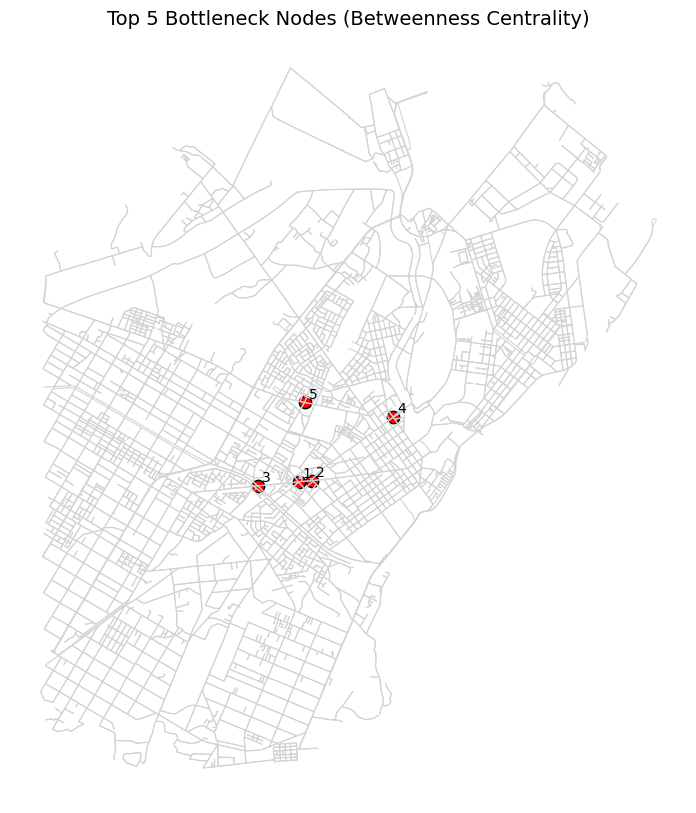

In [ ]:
# ============================================================
# Cell 7 — Betweenness Centrality and Top 5 Bottleneck Nodes
# ============================================================

# ------------------------------------------------------------
# 1. Calculate betweenness centrality
# ------------------------------------------------------------
print("⏳ Calculating betweenness centrality...")

# 使用 length 當作加權，符合作業要求的 bottleneck 診斷邏輯
centrality = nx.betweenness_centrality(
    G_proj,
    weight="length",
    normalized=True
)

print("✅ Betweenness centrality calculation complete")
print(f"Total nodes evaluated: {len(centrality)}")

# ------------------------------------------------------------
# 2. Extract Top 5 bottleneck nodes
# ------------------------------------------------------------
top_5_nodes = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:5]

print("\n✅ Top 5 bottleneck nodes identified")
for i, (node_id, cent_value) in enumerate(top_5_nodes, start=1):
    print(f"#{i}: Node {node_id}, centrality = {cent_value:.6f}")

# ------------------------------------------------------------
# 3. Convert Top 5 nodes to GeoDataFrame
# ------------------------------------------------------------
top_5_gdf = gpd.GeoDataFrame(
    [
        {
            "rank": i,
            "node_id": node_id,
            "centrality": cent_value,
            "geometry": Point(G_proj.nodes[node_id]["x"], G_proj.nodes[node_id]["y"])
        }
        for i, (node_id, cent_value) in enumerate(top_5_nodes, start=1)
    ],
    crs=G_proj.graph["crs"]
)

print("\n✅ Top 5 bottleneck nodes converted to GeoDataFrame")
display(top_5_gdf[["rank", "node_id", "centrality"]])

# ------------------------------------------------------------
# 4. Visualize road network + Top 5 bottlenecks
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# 把 graph 轉成 GeoDataFrame
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)

# 畫路網
edges_gdf.plot(ax=ax, linewidth=0.8, color="lightgray")

# 畫 Top 5 bottleneck nodes
top_5_gdf.plot(
    ax=ax,
    markersize=80,
    color="red",
    edgecolor="black"
)

# 加上 rank 標註
for _, row in top_5_gdf.iterrows():
    ax.annotate(
        text=str(row["rank"]),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=10,
        color="black"
    )

ax.set_title("Top 5 Bottleneck Nodes (Betweenness Centrality)", fontsize=14)
ax.set_axis_off()
plt.show()

#### step 8 ：Apply Kriging Rainfall Raster to Road Network

In [14]:
# ============================================================
# Cell 8 — Apply Kriging Rainfall Raster to Road Network
# ============================================================

from shapely.geometry import LineString
import numpy as np

# ------------------------------------------------------------
# 1. Define rainfall -> congestion function
# ------------------------------------------------------------
def rain_to_congestion(rainfall_mm, method="threshold"):
    """
    Convert rainfall (mm/hr) to congestion factor (cf).
    Homework-Week7 / Slide 12 logic.
    """
    if rainfall_mm is None or np.isnan(rainfall_mm):
        return 0.0

    rain = max(float(rainfall_mm), 0.0)

    if method == "threshold":
        if rain < CONGESTION_BREAK_1:
            return 0.0
        elif rain < CONGESTION_BREAK_2:
            return 0.3
        elif rain < CONGESTION_BREAK_3:
            return 0.6
        else:
            return 0.9

    elif method == "linear":
        return min((rain / 100.0) * 0.9, 0.9)

    elif method == "exponential":
        return min(0.95 * (1 - np.exp(-rain / 50.0)), 0.9)

    else:
        raise ValueError("method must be 'threshold', 'linear', or 'exponential'")


# ------------------------------------------------------------
# 2. Open kriging rainfall raster
# ------------------------------------------------------------
if not KRIGING_RAINFALL_PATH.exists():
    raise FileNotFoundError(f"Kriging rainfall raster not found: {KRIGING_RAINFALL_PATH}")

src = rasterio.open(KRIGING_RAINFALL_PATH)

print("✅ Kriging rainfall raster opened")
print("Raster CRS:", src.crs)
print("Raster bounds:", src.bounds)
print("Raster nodata:", src.nodata)


# ------------------------------------------------------------
# 3. Ensure graph CRS matches raster CRS
# ------------------------------------------------------------
graph_crs = str(G_proj.graph["crs"])
raster_crs = str(src.crs)

if graph_crs != raster_crs:
    raise ValueError(
        f"CRS mismatch: graph CRS = {graph_crs}, raster CRS = {raster_crs}. "
        "Please reproject one of them before continuing."
    )

print("✅ Graph CRS matches raster CRS")


# ------------------------------------------------------------
# 4. Sample rainfall at edge midpoint and compute adjusted travel time
# ------------------------------------------------------------
edge_rainfall_records = []

for u, v, k, data in G_proj.edges(keys=True, data=True):
    geom = data.get("geometry", None)

    # 若 edge 沒有 geometry，就用起終點補一條線
    if geom is None:
        x1, y1 = G_proj.nodes[u]["x"], G_proj.nodes[u]["y"]
        x2, y2 = G_proj.nodes[v]["x"], G_proj.nodes[v]["y"]
        geom = LineString([(x1, y1), (x2, y2)])

    midpoint = geom.interpolate(0.5, normalized=True)

    # raster sampling
    sampled_value = list(src.sample([(midpoint.x, midpoint.y)]))[0][0]

    # nodata handling
    if src.nodata is not None and sampled_value == src.nodata:
        rainfall_mm = np.nan
    else:
        rainfall_mm = float(sampled_value)

    cf = rain_to_congestion(rainfall_mm, method=CONGESTION_METHOD)

    # 原本的災前 travel_time
    travel_time = float(data.get("travel_time", np.nan))

    # 災後 travel_time_adj
    if np.isnan(travel_time):
        travel_time_adj = np.nan
    else:
        # avoid division by zero if cf accidentally reaches 1
        denom = max(1.0 - cf, 0.05)
        travel_time_adj = travel_time / denom

    # write back to graph
    data["rainfall_mm"] = rainfall_mm
    data["congestion_factor"] = cf
    data["travel_time_adj"] = travel_time_adj

    edge_rainfall_records.append({
        "u": u,
        "v": v,
        "key": k,
        "rainfall_mm": rainfall_mm,
        "congestion_factor": cf,
        "travel_time": travel_time,
        "travel_time_adj": travel_time_adj
    })

edge_rainfall_df = pd.DataFrame(edge_rainfall_records)

print("\n✅ Rainfall and adjusted travel time assigned to all edges")
print(f"Total edges processed: {len(edge_rainfall_df)}")

print("\n--- Rainfall summary (mm/hr) ---")
print(edge_rainfall_df["rainfall_mm"].describe())

print("\n--- Congestion factor distribution ---")
print(edge_rainfall_df["congestion_factor"].value_counts().sort_index())

print("\n--- travel_time_adj summary (sec) ---")
print(edge_rainfall_df["travel_time_adj"].describe())


# ------------------------------------------------------------
# 5. Close raster
# ------------------------------------------------------------
src.close()
print("\n✅ Raster closed")

✅ Kriging rainfall raster opened
Raster CRS: EPSG:3826
Raster bounds: BoundingBox(left=264261.4365865011, bottom=2558311.2847853773, right=351033.5866224941, top=2768948.1795328944)
Raster nodata: -9999.0
✅ Graph CRS matches raster CRS

✅ Rainfall and adjusted travel time assigned to all edges
Total edges processed: 9815

--- Rainfall summary (mm/hr) ---
count    9815.000000
mean        0.744127
std         0.049917
min         0.645965
25%         0.701952
50%         0.745597
75%         0.780582
max         0.864141
Name: rainfall_mm, dtype: float64

--- Congestion factor distribution ---
congestion_factor
0.0    9815
Name: count, dtype: int64

--- travel_time_adj summary (sec) ---
count    9815.000000
mean       10.189927
std        10.084700
min         0.273778
25%         4.787576
50%         7.421554
75%        12.104620
max       157.444815
Name: travel_time_adj, dtype: float64

✅ Raster closed


#### step9：Compute Pre/Post Isochrones and Accessibility Impact Table

In [15]:
# ============================================================
# Cell 9 — Compute Pre/Post Isochrones and Accessibility Impact Table
# ============================================================

from shapely.geometry import MultiPoint

# ------------------------------------------------------------
# 1. Helper: compute reachable nodes within time threshold
# ------------------------------------------------------------
def compute_reachable_nodes(G, source_node, weight_field, time_threshold_sec):
    """
    Return reachable node IDs within a given travel-time threshold.
    """
    travel_times = nx.single_source_dijkstra_path_length(
        G,
        source=source_node,
        weight=weight_field
    )
    reachable_nodes = [node for node, t in travel_times.items() if t <= time_threshold_sec]
    return reachable_nodes


# ------------------------------------------------------------
# 2. Helper: convert reachable nodes to simple polygon
# ------------------------------------------------------------
def reachable_nodes_to_polygon(G, reachable_nodes):
    """
    Convert reachable nodes to polygon using convex hull.
    (Simple and stable version for homework workflow)
    """
    if len(reachable_nodes) < 3:
        return None

    points = [
        Point(G.nodes[node]["x"], G.nodes[node]["y"])
        for node in reachable_nodes
        if "x" in G.nodes[node] and "y" in G.nodes[node]
    ]

    if len(points) < 3:
        return None

    return MultiPoint(points).convex_hull


# ------------------------------------------------------------
# 3. Compute pre/post isochrones for each facility
# ------------------------------------------------------------
iso_results = []
isochrone_polygons = []

for _, facility in selected_facilities_gdf.iterrows():
    facility_id = facility["facility_id"]
    facility_name = facility["facility_name"]
    source_node = facility["nearest_node"]

    row_result = {
        "facility_id": facility_id,
        "facility_name": facility_name,
        "facility_risk_level": facility["facility_risk_level"],
        "capacity": facility["capacity"]
    }

    for minutes in ISOCHRONE_MINUTES:
        threshold_sec = minutes * 60

        # Pre-disaster
        pre_nodes = compute_reachable_nodes(
            G_proj,
            source_node=source_node,
            weight_field="travel_time",
            time_threshold_sec=threshold_sec
        )
        pre_poly = reachable_nodes_to_polygon(G_proj, pre_nodes)
        pre_area_km2 = pre_poly.area / 1_000_000 if pre_poly is not None else 0.0

        # Post-disaster
        post_nodes = compute_reachable_nodes(
            G_proj,
            source_node=source_node,
            weight_field="travel_time_adj",
            time_threshold_sec=threshold_sec
        )
        post_poly = reachable_nodes_to_polygon(G_proj, post_nodes)
        post_area_km2 = post_poly.area / 1_000_000 if post_poly is not None else 0.0

        # Shrinkage ratio
        if pre_area_km2 > 0:
            shrinkage = 1 - (post_area_km2 / pre_area_km2)
        else:
            shrinkage = np.nan

        # write summary table fields
        row_result[f"pre_{minutes}min_km2"] = pre_area_km2
        row_result[f"post_{minutes}min_km2"] = post_area_km2
        row_result[f"shrinkage_{minutes}min"] = shrinkage

        # save polygons for optional plotting
        if pre_poly is not None:
            isochrone_polygons.append({
                "facility_id": facility_id,
                "facility_name": facility_name,
                "scenario": "pre",
                "minutes": minutes,
                "geometry": pre_poly
            })

        if post_poly is not None:
            isochrone_polygons.append({
                "facility_id": facility_id,
                "facility_name": facility_name,
                "scenario": "post",
                "minutes": minutes,
                "geometry": post_poly
            })

    iso_results.append(row_result)

# ------------------------------------------------------------
# 4. Create accessibility impact table
# ------------------------------------------------------------
accessibility_table = pd.DataFrame(iso_results)

print("✅ Accessibility impact table created")
display(accessibility_table)

# ------------------------------------------------------------
# 5. Convert polygons to GeoDataFrame (for later visualization)
# ------------------------------------------------------------
if len(isochrone_polygons) > 0:
    isochrone_gdf = gpd.GeoDataFrame(isochrone_polygons, crs=G_proj.graph["crs"])
    print("\n✅ Isochrone polygon GeoDataFrame created")
    print("Isochrone polygon count:", len(isochrone_gdf))
else:
    isochrone_gdf = gpd.GeoDataFrame(columns=["facility_id", "facility_name", "scenario", "minutes", "geometry"], crs=G_proj.graph["crs"])
    print("\n⚠️ No valid isochrone polygons were generated")

✅ Accessibility impact table created


,facility_id,facility_name,facility_risk_level,capacity,pre_5min_km2,post_5min_km2,shrinkage_5min,pre_10min_km2,post_10min_km2,shrinkage_10min
0,F1,中正國小,中風險,187,24.737135,24.737135,0.0,60.430901,60.430901,0.0
1,F2,中原國小文中三國中預定地,高風險,85,25.678171,25.678171,0.0,60.013269,60.013269,0.0
2,F3,忠孝國小,中風險,47,22.393526,22.393526,0.0,62.024956,62.024956,0.0
3,F4,主權社區活動中心,中風險,72,24.333173,24.333173,0.0,60.740283,60.740283,0.0
4,F5,國風國中,中風險,800,22.329930,22.329930,0.0,60.999962,60.999962,0.0



✅ Isochrone polygon GeoDataFrame created
Isochrone polygon count: 20


#### step 10：Visualize Pre/Post Isochrones for the 5 Facilities

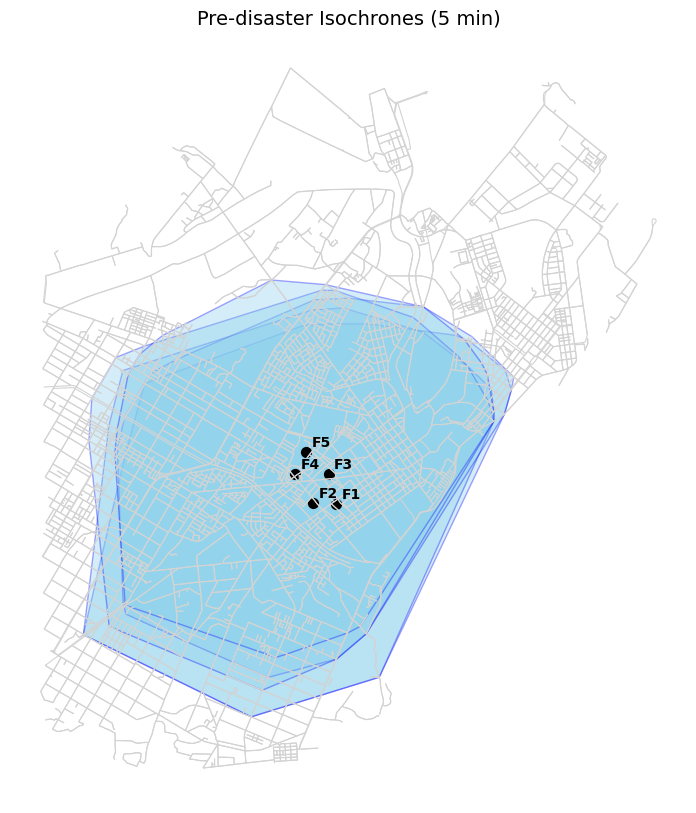

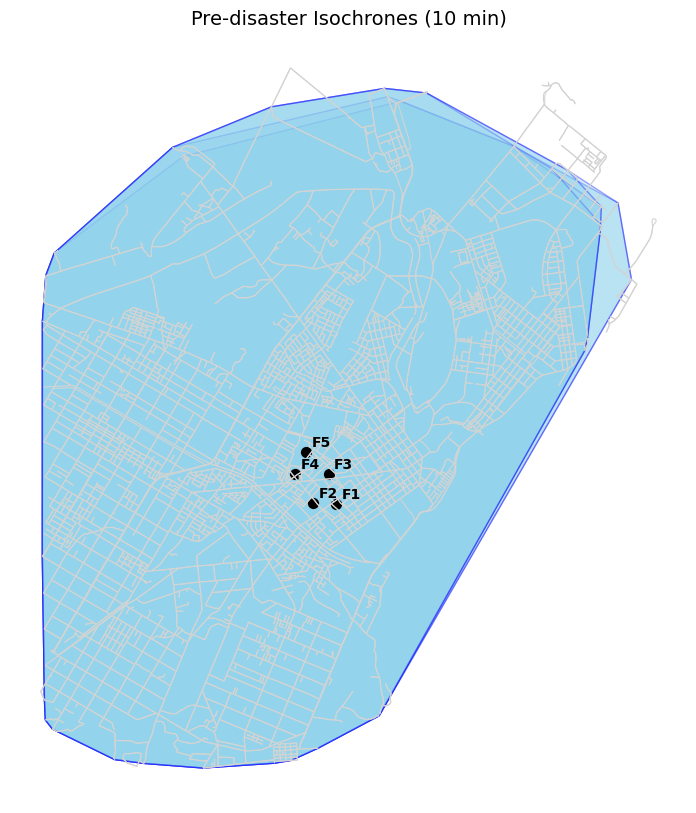

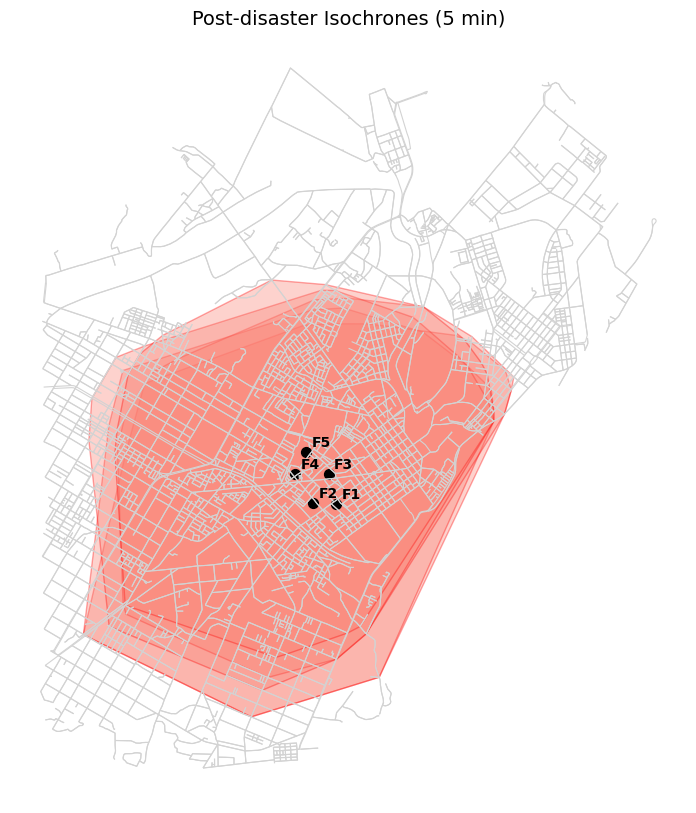

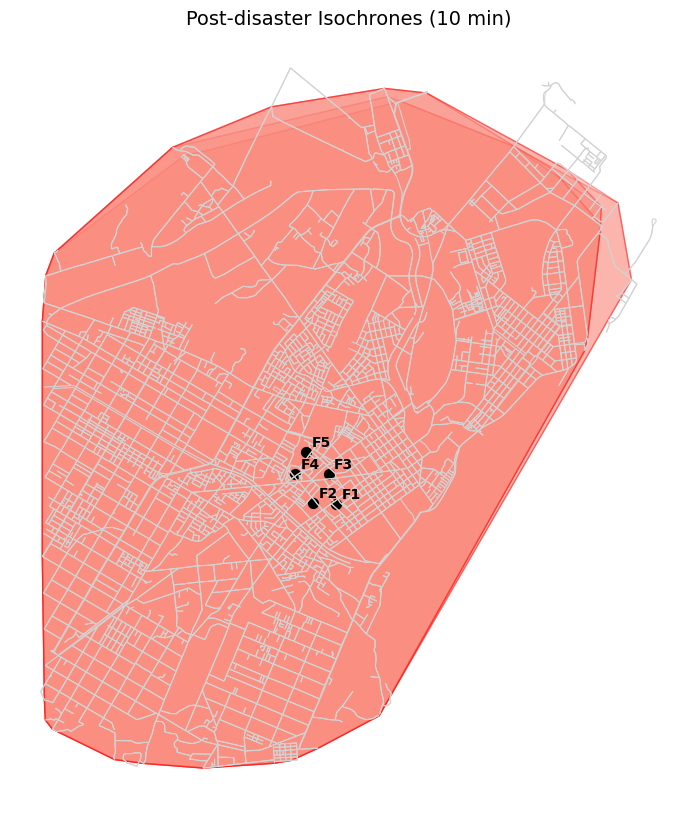

In [17]:
# ============================================================
# Cell 10 — Visualize Pre and Post Isochrones Separately
# ============================================================

# 1. 準備 road network GeoDataFrame
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)

# 2. 確保設施與 isochrone 都在 graph CRS
facilities_plot_gdf = selected_facilities_gdf.to_crs(G_proj.graph["crs"]).copy()
iso_plot_gdf = isochrone_gdf.to_crs(G_proj.graph["crs"]).copy()

# 3. 依 scenario（pre / post）與 minutes（5 / 10）分別畫圖
for scenario in ["pre", "post"]:
    for minutes in ISOCHRONE_MINUTES:
        fig, ax = plt.subplots(figsize=(10, 10))

        # 畫底圖：road network
        edges_gdf.plot(ax=ax, linewidth=0.8, color="lightgray")

        # 篩選對應的 isochrone
        plot_gdf = iso_plot_gdf[
            (iso_plot_gdf["minutes"] == minutes) &
            (iso_plot_gdf["scenario"] == scenario)
        ].copy()

        # 畫 isochrone polygon
        if len(plot_gdf) > 0:
            if scenario == "pre":
                plot_gdf.plot(
                    ax=ax,
                    facecolor="skyblue",
                    edgecolor="blue",
                    alpha=0.35,
                    linewidth=1.0
                )
            else:
                plot_gdf.plot(
                    ax=ax,
                    facecolor="salmon",
                    edgecolor="red",
                    alpha=0.35,
                    linewidth=1.0
                )

        # 畫設施點
        facilities_plot_gdf.plot(
            ax=ax,
            color="black",
            markersize=50,
            marker="o"
        )

        # 標註 facility_id
        for _, row in facilities_plot_gdf.iterrows():
            ax.annotate(
                text=row["facility_id"],
                xy=(row.geometry.x, row.geometry.y),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=10,
                color="black",
                fontweight="bold"
            )

        # 標題
        scenario_label = "Pre-disaster" if scenario == "pre" else "Post-disaster"
        ax.set_title(f"{scenario_label} Isochrones ({minutes} min)", fontsize=14)

        ax.set_axis_off()
        plt.show()

#### step11： AI Bonus: Generate Strategic Briefing

In [30]:
# ============================================================
# Cell 11 — AI Bonus: Generate Strategic Briefing
# Robust version with quota-aware retry + model fallback
# ============================================================

import os
import re
import time
from pathlib import Path
from dotenv import load_dotenv

# ------------------------------------------------------------
# 0. Load .env explicitly
# ------------------------------------------------------------
env_path_for_ai = Path("../.env").resolve()

if not env_path_for_ai.exists():
    raise FileNotFoundError(f".env file not found: {env_path_for_ai}")

load_dotenv(dotenv_path=env_path_for_ai, override=True)

google_api_key = os.getenv("GOOGLE_API_KEY")
llm_provider = os.getenv("LLM_PROVIDER", "gemini").lower()

print(f"✅ .env loaded from: {env_path_for_ai}")
print(f"Selected LLM provider: {llm_provider}")

# ------------------------------------------------------------
# 1. Prepare structured summaries
# ------------------------------------------------------------
top5_info = "\n".join([
    f"#{row['rank']}: Node {row['node_id']}, centrality = {row['centrality']:.6f}"
    for _, row in top_5_gdf.sort_values("rank").iterrows()
])

accessibility_table_str = accessibility_table.to_string(index=False)

isolated_mask = (
    (accessibility_table["post_10min_km2"] == 0) |
    (accessibility_table["shrinkage_10min"] >= 0.5)
)

isolated_facilities_df = accessibility_table.loc[isolated_mask, [
    "facility_id", "facility_name", "post_10min_km2", "shrinkage_10min"
]].copy()

if len(isolated_facilities_df) == 0:
    isolated_facilities_str = "None. No facility met the current isolation threshold."
else:
    isolated_facilities_str = isolated_facilities_df.to_string(index=False)

# ------------------------------------------------------------
# 2. Build AI prompt
# ------------------------------------------------------------
ai_prompt = f"""
You are acting as a Transportation Advisor for the Hualien County Disaster Prevention Command Center.

Below are the road network analysis results from this study:

[Top 5 Bottleneck Nodes]
{top5_info}

[Accessibility Impact Table]
{accessibility_table_str}

[Isolated / Highly Impacted Facilities]
{isolated_facilities_str}

Based on the results above, please prepare a professional disaster-response strategy briefing. Your response should include at least the following:

1. Which road nodes or surrounding areas should be prioritized for clearance or inspection, and why
2. Which shelters or facilities should receive priority attention
3. What alternative rescue strategies could be adopted if some areas become difficult to access (for example: rubber boats, alternative routes, temporary staging points, etc.)
4. Recommendations for resource allocation priority
5. A short overall conclusion that decision-makers can quickly understand

Please write in clear, well-structured, professional English that can be directly included in a homework report.
"""

print("✅ AI prompt prepared")

# ------------------------------------------------------------
# 3. Save prompt locally
# ------------------------------------------------------------
ai_prompt_path = OUTPUT_DIR / "ai_bonus_prompt.txt"
with open(ai_prompt_path, "w", encoding="utf-8") as f:
    f.write(ai_prompt)

print(f"✅ AI prompt saved to: {ai_prompt_path}")

# ------------------------------------------------------------
# 4. Prepare manual fallback template
# ------------------------------------------------------------
manual_ai_response_template = f"""# AI Strategy Briefing (Manual Fallback)

## Usage Note
Automatic Gemini invocation was not completed successfully in the notebook environment.
You can manually paste the exported prompt into ChatGPT, Gemini, or Claude.

Prompt file:
- {ai_prompt_path.name}

## Suggested AI Output (Paste your AI-generated result below)

### 1. Priority road nodes / areas to inspect
[Paste AI response here]

### 2. Priority shelters / facilities to monitor
[Paste AI response here]

### 3. Alternative rescue strategies
[Paste AI response here]

### 4. Resource allocation priority
[Paste AI response here]

### 5. Overall conclusion
[Paste AI response here]
"""

manual_ai_md_path = OUTPUT_DIR / "ai_strategy_briefing_manual_template.md"
with open(manual_ai_md_path, "w", encoding="utf-8") as f:
    f.write(manual_ai_response_template)

print(f"✅ Manual fallback template saved to: {manual_ai_md_path}")

# ------------------------------------------------------------
# 5. Helper functions
# ------------------------------------------------------------
def extract_retry_seconds(error_text, default_seconds=20):
    """
    Try to parse retry delay from Gemini quota error message.
    """
    if not error_text:
        return default_seconds

    # Match patterns like "Please retry in 16.934169891s"
    m = re.search(r"retry in\s+([0-9]+(?:\.[0-9]+)?)s", error_text, flags=re.IGNORECASE)
    if m:
        return max(1, int(float(m.group(1)) + 1))

    # Match patterns like "seconds: 16"
    m = re.search(r"seconds:\s*([0-9]+)", error_text, flags=re.IGNORECASE)
    if m:
        return max(1, int(m.group(1)) + 1)

    return default_seconds


def sort_candidate_models(model_names):
    """
    Prefer cheaper / lighter models first to reduce quota pressure.
    """
    priority_keywords = [
        "flash-lite",
        "flash",
        "pro",
    ]

    def score(name):
        lname = name.lower()
        for i, kw in enumerate(priority_keywords):
            if kw in lname:
                return i
        return 99

    return sorted(model_names, key=score)


# ------------------------------------------------------------
# 6. Try Gemini invocation
# ------------------------------------------------------------
ai_response_text = None
used_model_name = None
ai_status = "not_attempted"
ai_error_message = None

if llm_provider != "gemini":
    ai_status = "provider_not_gemini"
    print("⚠️ LLM_PROVIDER is not 'gemini'. Automatic Gemini invocation skipped.")
    print("You can manually use the saved prompt with your preferred AI tool.")

elif not google_api_key:
    ai_status = "no_api_key"
    print("⚠️ GOOGLE_API_KEY not found in .env")
    print("You can manually use the saved prompt with ChatGPT / Gemini / Claude.")

elif google_api_key.strip().lower() in ["your-gemini-api-key-here", "your_google_api_key_here", ""]:
    ai_status = "placeholder_api_key"
    print("⚠️ GOOGLE_API_KEY is still a placeholder, not a real key.")
    print("You can manually use the saved prompt with ChatGPT / Gemini / Claude.")

else:
    try:
        import google.generativeai as genai

        genai.configure(api_key=google_api_key)

        # 列出可用模型
        available_models = []
        for m in genai.list_models():
            methods = getattr(m, "supported_generation_methods", [])
            if "generateContent" in methods:
                available_models.append(m.name)

        if len(available_models) == 0:
            ai_status = "no_available_model"
            print("⚠️ No Gemini model supporting generateContent was found.")
            print("Please use the saved prompt manually.")
        else:
            candidate_models = sort_candidate_models(available_models)

            print("\nUsable Gemini models (sorted):")
            for name in candidate_models:
                print("-", name)

            # 最多嘗試前 3 個模型，避免打太多 quota
            models_to_try = candidate_models[:3]

            max_retries_per_model = 2

            for model_name in models_to_try:
                print(f"\n🔍 Trying model: {model_name}")

                for attempt in range(1, max_retries_per_model + 1):
                    try:
                        print(f"Attempt {attempt}/{max_retries_per_model}")
                        model = genai.GenerativeModel(model_name)
                        response = model.generate_content(ai_prompt)

                        ai_response_text = response.text
                        used_model_name = model_name
                        ai_status = "success"
                        break

                    except Exception as e:
                        err = str(e)
                        ai_error_message = err

                        # quota exceeded -> wait and retry
                        if "429" in err or "quota" in err.lower() or "rate" in err.lower():
                            wait_sec = extract_retry_seconds(err, default_seconds=20)
                            print(f"⚠️ Quota/rate limit hit for {model_name}. Waiting {wait_sec} seconds before retry...")
                            time.sleep(wait_sec)
                        else:
                            print(f"⚠️ Model {model_name} failed with non-quota error:")
                            print(err)
                            break

                if ai_status == "success":
                    break

            if ai_status == "success":
                print(f"\n✅ AI Strategy Briefing generated successfully with model: {used_model_name}")
                print("\n" + "=" * 60)
                print(ai_response_text)
                print("=" * 60)
            else:
                ai_status = "failed"
                print("⚠️ Gemini invocation failed after trying multiple models/retries.")
                print("Please use the saved prompt manually in ChatGPT / Gemini / Claude.")

    except Exception as e:
        ai_status = "failed"
        ai_error_message = str(e)
        print("⚠️ Gemini setup/invocation failed.")
        print("Error message:", ai_error_message)
        print("Please use the saved prompt manually in ChatGPT / Gemini / Claude.")

# ------------------------------------------------------------
# 7. Save AI response if available
# ------------------------------------------------------------
if ai_response_text is not None:
    ai_response_path = OUTPUT_DIR / "ai_strategy_briefing.md"
    with open(ai_response_path, "w", encoding="utf-8") as f:
        f.write("# AI Strategy Briefing\n\n")
        f.write(f"Model: {used_model_name}\n\n")
        f.write(ai_response_text)

    print(f"\n✅ AI response saved to: {ai_response_path}")
else:
    print("\nℹ️ No automatic AI response file created.")
    print("You can now open the following files and complete the bonus manually:")
    print(f"- Prompt file: {ai_prompt_path}")
    print(f"- Manual template: {manual_ai_md_path}")

# ------------------------------------------------------------
# 8. Save AI run log
# ------------------------------------------------------------
ai_log_lines = [
    f"ai_status: {ai_status}",
    f"env_path: {env_path_for_ai}",
    f"prompt_file: {ai_prompt_path}",
    f"manual_template_file: {manual_ai_md_path}",
]

if used_model_name is not None:
    ai_log_lines.append(f"used_model_name: {used_model_name}")

if ai_error_message is not None:
    ai_log_lines.append(f"error_message: {ai_error_message}")

ai_log_path = OUTPUT_DIR / "ai_bonus_run_log.txt"
with open(ai_log_path, "w", encoding="utf-8") as f:
    f.write("\n".join(ai_log_lines))

print(f"✅ AI run log saved to: {ai_log_path}")

✅ .env loaded from: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\.env
Selected LLM provider: gemini
✅ AI prompt prepared
✅ AI prompt saved to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\ai_bonus_prompt.txt
✅ Manual fallback template saved to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\ai_strategy_briefing_manual_template.md

Usable Gemini models (sorted):
- models/gemini-2.0-flash-lite-001
- models/gemini-2.0-flash-lite
- models/gemini-flash-lite-latest
- models/gemini-2.5-flash-lite
- models/gemini-3.1-flash-lite-preview
- models/gemini-2.5-flash
- models/gemini-2.0-flash
- models/gemini-2.0-flash-001
- models/gemini-2.5-flash-preview-tts
- models/gemini-flash-latest
- models/gemini-2.5-flash-image
- models/gemini-3-flash-preview
- models/gemini-3.1-flash-image-preview
- models/gemini-2.5-pro
- models/gemini-2.5-pro-preview-tts
- models/gemini-pro-latest
- models/gemini-3-pro-previ

#### step12：Export Tables and Generate Summary for README

In [31]:
# ============================================================
# Cell 12 — Export Tables and Generate Summary for README
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Export core tables
# ------------------------------------------------------------
accessibility_csv_path = OUTPUT_DIR / "accessibility_impact_table.csv"
top5_csv_path = OUTPUT_DIR / "top5_bottleneck_nodes.csv"
facilities_csv_path = OUTPUT_DIR / "selected_facilities.csv"

accessibility_table.to_csv(accessibility_csv_path, index=False, encoding="utf-8-sig")
top_5_gdf.drop(columns="geometry").to_csv(top5_csv_path, index=False, encoding="utf-8-sig")
selected_facilities_gdf.drop(columns="geometry").to_csv(facilities_csv_path, index=False, encoding="utf-8-sig")

print(f"✅ accessibility_table exported to: {accessibility_csv_path}")
print(f"✅ top_5_gdf exported to: {top5_csv_path}")
print(f"✅ selected_facilities_gdf exported to: {facilities_csv_path}")

# ------------------------------------------------------------
# 2. Compute summary statistics
# ------------------------------------------------------------
# top bottleneck
top1_bottleneck = top_5_gdf.sort_values("centrality", ascending=False).iloc[0]

# largest capacity facility
largest_capacity_row = selected_facilities_gdf.loc[selected_facilities_gdf["capacity"].idxmax()]

# max shrinkage
shrinkage_cols = [c for c in accessibility_table.columns if c.startswith("shrinkage_")]
if len(shrinkage_cols) > 0:
    max_shrinkage = accessibility_table[shrinkage_cols].max().max()
else:
    max_shrinkage = np.nan

# detect if all shrinkage values are 0
if len(shrinkage_cols) > 0:
    all_zero_shrinkage = (accessibility_table[shrinkage_cols].fillna(0) == 0).all().all()
else:
    all_zero_shrinkage = False

# ------------------------------------------------------------
# 3. Check AI bonus outputs
# ------------------------------------------------------------
ai_prompt_path = OUTPUT_DIR / "ai_bonus_prompt.txt"
ai_manual_template_path = OUTPUT_DIR / "ai_strategy_briefing_manual_template.md"
ai_response_path = OUTPUT_DIR / "ai_strategy_briefing.md"
ai_log_path = OUTPUT_DIR / "ai_bonus_run_log.txt"

ai_status = "unknown"
ai_status_detail = ""

if ai_log_path.exists():
    with open(ai_log_path, "r", encoding="utf-8") as f:
        ai_log_text = f.read()

    for line in ai_log_text.splitlines():
        if line.startswith("ai_status:"):
            ai_status = line.split(":", 1)[1].strip()
        if line.startswith("error_message:"):
            ai_status_detail = line.split(":", 1)[1].strip()

# ------------------------------------------------------------
# 4. Build README-style markdown summary
# ------------------------------------------------------------
summary_lines = []
summary_lines.append("# ARIA v4.0 — Homework-Week7 Summary")
summary_lines.append("")
summary_lines.append("## Project Overview")
summary_lines.append(
    "This homework develops a network-based disaster accessibility assessment workflow in Hualien, "
    "integrating road network data, shelter/facility data, and kriging rainfall results."
)
summary_lines.append("")
summary_lines.append("## Key Results")
summary_lines.append(f"- Total road network nodes: **{G_proj.number_of_nodes()}**")
summary_lines.append(f"- Total road network edges: **{G_proj.number_of_edges()}**")
summary_lines.append(
    f"- Top bottleneck node: **{int(top1_bottleneck['node_id'])}** "
    f"(centrality = **{top1_bottleneck['centrality']:.6f}**)"
)
summary_lines.append(
    f"- Highest-capacity selected facility: **{largest_capacity_row['facility_name']}** "
    f"(capacity = **{largest_capacity_row['capacity']}**)"
)
summary_lines.append(f"- Maximum accessibility shrinkage observed: **{max_shrinkage:.4f}**")
summary_lines.append("")

summary_lines.append("## Interpretation")
if all_zero_shrinkage:
    summary_lines.append(
        "- In the current analysis, sampled rainfall values from the kriging raster were all below the congestion threshold."
    )
    summary_lines.append(
        "- Therefore, the congestion factor remained 0.0 on all road segments, and post-disaster travel time was identical to pre-disaster travel time."
    )
    summary_lines.append(
        "- As a result, pre-disaster and post-disaster isochrone areas were the same, and all shrinkage values were 0.0."
    )
else:
    summary_lines.append(
        "- The comparison between pre-disaster and post-disaster isochrones shows measurable accessibility loss for at least some facilities."
    )
    summary_lines.append(
        "- The shrinkage ratio can be used to identify facilities most affected by rainfall-induced traffic disruption."
    )

summary_lines.append("")
summary_lines.append("## Selected Facilities")
for _, row in selected_facilities_gdf.iterrows():
    summary_lines.append(
        f"- **{row['facility_id']}** — {row['facility_name']} "
        f"({row['admin_area']}, risk = {row['facility_risk_level']}, capacity = {row['capacity']})"
    )

summary_lines.append("")
summary_lines.append("## Output Files")
summary_lines.append(f"- Accessibility impact table: `{accessibility_csv_path.name}`")
summary_lines.append(f"- Top 5 bottleneck nodes: `{top5_csv_path.name}`")
summary_lines.append(f"- Selected facilities: `{facilities_csv_path.name}`")

if ai_prompt_path.exists():
    summary_lines.append(f"- AI bonus prompt: `{ai_prompt_path.name}`")
if ai_manual_template_path.exists():
    summary_lines.append(f"- AI bonus manual template: `{ai_manual_template_path.name}`")
if ai_response_path.exists():
    summary_lines.append(f"- AI strategy briefing: `{ai_response_path.name}`")
if ai_log_path.exists():
    summary_lines.append(f"- AI run log: `{ai_log_path.name}`")

summary_lines.append("")
summary_lines.append("## AI Bonus Status")
summary_lines.append(f"- AI status: **{ai_status}**")

if ai_status == "success":
    summary_lines.append("- The AI-generated strategy briefing was successfully created and saved.")
elif ai_status in ["failed", "no_api_key", "placeholder_api_key", "no_available_model", "provider_not_gemini"]:
    summary_lines.append("- Automatic AI generation was not completed successfully.")
    if ai_status_detail:
        summary_lines.append(f"- Error detail: `{ai_status_detail}`")
    summary_lines.append("- Manual fallback files were generated so the bonus can still be completed manually.")
else:
    summary_lines.append("- AI bonus execution status could not be fully determined from the current logs.")

summary_lines.append("")
summary_lines.append("## Notes")
summary_lines.append("- Road network CRS was standardized to **EPSG:3826**.")
summary_lines.append("- Travel time was computed from road length and maxspeed, with a default speed used when necessary.")
summary_lines.append("- Isochrone analysis was performed for **5-minute** and **10-minute** thresholds.")
summary_lines.append("- The current workflow used the **Week 6 kriging rainfall raster** as the rainfall source.")
summary_lines.append("- Top 5 bottleneck nodes were identified using **betweenness centrality**.")

readme_summary_text = "\n".join(summary_lines)

# ------------------------------------------------------------
# 5. Save README summary markdown
# ------------------------------------------------------------
summary_md_path = OUTPUT_DIR / "homework_week7_summary.md"
with open(summary_md_path, "w", encoding="utf-8") as f:
    f.write(readme_summary_text)

print(f"✅ README-style summary exported to: {summary_md_path}")

# ------------------------------------------------------------
# 6. Display summary in notebook
# ------------------------------------------------------------
print("\n" + "=" * 70)
print(readme_summary_text)
print("=" * 70)

✅ accessibility_table exported to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\accessibility_impact_table.csv
✅ top_5_gdf exported to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\top5_bottleneck_nodes.csv
✅ selected_facilities_gdf exported to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\selected_facilities.csv
✅ README-style summary exported to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\homework_week7_summary.md

# ARIA v4.0 — Homework-Week7 Summary

## Project Overview
This homework develops a network-based disaster accessibility assessment workflow in Hualien, integrating road network data, shelter/facility data, and kriging rainfall results.

## Key Results
- Total road network nodes: **3421**
- Total road network edges: **9815**
- Top bottleneck node: **649286213** (centrality = **0.140247**)
- Highest-capacity selected facility: **國風

#### step13：Generate README.md Framework / Final README Export

In [32]:
# ============================================================
# Cell 13 — Generate README.md Framework / Final README Export
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# 1. Locate summary file from Cell 12
# ------------------------------------------------------------
summary_md_path = OUTPUT_DIR / "homework_week7_summary.md"

if not summary_md_path.exists():
    raise FileNotFoundError(
        f"Summary file not found: {summary_md_path}. Please run Cell 12 first."
    )

with open(summary_md_path, "r", encoding="utf-8") as f:
    summary_text = f.read()

# ------------------------------------------------------------
# 2. Prepare README framework
# ------------------------------------------------------------
readme_text = f"""# ARIA v4.0 - Hualien Disaster Accessibility Assessment

## Project Overview

This project builds an integrated disaster accessibility assessment workflow for Hualien, Taiwan, by combining:

- road network analysis
- shelter / facility accessibility analysis
- bottleneck diagnosis based on betweenness centrality
- rainfall impact assessment using the Week 6 kriging rainfall raster
- pre-disaster and post-disaster isochrone comparison

The objective is to assess whether key facilities remain reachable under disaster conditions and to identify transportation bottlenecks, accessibility loss, and priority response strategies.

---

## Data Sources

- **Road network**: OpenStreetMap (via OSMnx)
- **Shelter / facility data**: `shelters_with_risk.geojson`
- **Terrain / facility audit data**: `terrain_risk_audit.geojson`
- **Rainfall data**: `kriging_rainfall.tif` (Week 6 kriging output)

---

## Workflow Summary

1. Load and standardize shelter / facility data
2. Select 5 key facilities for analysis
3. Download or load the road network from OpenStreetMap
4. Project the network to EPSG:3826
5. Compute edge travel time from road length and speed
6. Identify Top 5 bottleneck nodes using betweenness centrality
7. Sample rainfall from the kriging raster at road segment midpoints
8. Convert rainfall values to congestion factors
9. Compute pre-disaster and post-disaster isochrones
10. Compare accessibility changes using shrinkage ratios
11. Generate AI bonus prompt / strategy briefing support files

---

## Deliverables

- `ARIA_v4.ipynb` — complete analysis notebook
- `accessibility_impact_table.csv`
- `top5_bottleneck_nodes.csv`
- `selected_facilities.csv`
- `homework_week7_summary.md`
- `README.md`

---

## AI Diagnostic Log

### 1. OSMnx road network extraction
**Issue:** Large network extent or repeated downloads may slow down notebook execution.  
**Solution:** The workflow saves and reuses GraphML files when possible to reduce repeated OSM downloads.

### 2. Isochrone comparison
**Issue:** In the current analysis, pre-disaster and post-disaster isochrones may appear identical.  
**Solution:** This is not a coding error. It occurs because sampled rainfall values were below the congestion threshold, resulting in congestion factors of 0.0.

### 3. Gemini API invocation
**Issue:** Automatic AI generation may fail due to API key issues, quota limits, or model availability.  
**Solution:** The notebook exports an AI prompt file and a manual fallback markdown template so the AI bonus can still be completed manually.

---

## Final Summary

{summary_text}

---

## Submission Checklist

- [ ] `ARIA_v4.ipynb`
- [ ] `accessibility_impact_table.csv`
- [ ] `top5_bottleneck_nodes.csv`
- [ ] `selected_facilities.csv`
- [ ] `README.md`

---

## Notes

- All major spatial analyses were standardized to **EPSG:3826**
- Isochrone comparison was performed for **5-minute** and **10-minute** thresholds
- The current workflow uses **betweenness centrality** for bottleneck detection
- The current rainfall source is the **Week 6 kriging raster**
- AI bonus results may be completed either automatically or manually, depending on API availability
"""

# ------------------------------------------------------------
# 3. Save final README.md
# ------------------------------------------------------------
readme_path = OUTPUT_DIR / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"✅ Final README exported to: {readme_path}")

# ------------------------------------------------------------
# 4. Also save a lighter template version
# ------------------------------------------------------------
readme_template_text = """# ARIA v4.0 - Hualien Disaster Accessibility Assessment

## Project Overview
[Write a short summary of your project here]

## Data Sources
- Road network:
- Shelter / facility data:
- Terrain / audit data:
- Rainfall data:

## Workflow Summary
1.
2.
3.

## Key Results
- Top bottleneck node:
- Maximum accessibility shrinkage:
- Most important facility:
- AI bonus status:

## AI Diagnostic Log
### 1. OSMnx extraction
**Issue:**  
**Solution:**  

### 2. Isochrone comparison
**Issue:**  
**Solution:**  

### 3. AI bonus
**Issue:**  
**Solution:**  

## Output Files
- accessibility_impact_table.csv
- top5_bottleneck_nodes.csv
- selected_facilities.csv
- README.md

## Submission Checklist
- [ ] ARIA_v4.ipynb
- [ ] accessibility_impact_table.csv
- [ ] top5_bottleneck_nodes.csv
- [ ] selected_facilities.csv
- [ ] README.md
"""

readme_template_path = OUTPUT_DIR / "README_template.md"
with open(readme_template_path, "w", encoding="utf-8") as f:
    f.write(readme_template_text)

print(f"✅ README template exported to: {readme_template_path}")

# ------------------------------------------------------------
# 5. Show README preview
# ------------------------------------------------------------
print("\n" + "=" * 70)
print(readme_text[:3000])  # 只預覽前 3000 字，避免輸出太長
print("\n... [README preview truncated] ...")
print("=" * 70)

✅ Final README exported to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\README.md
✅ README template exported to: C:\Users\97000\CascadeProjects\Remote-Sensing-and-Geospatial-Analysis\HW7\output\README_template.md

# ARIA v4.0 - Hualien Disaster Accessibility Assessment

## Project Overview

This project builds an integrated disaster accessibility assessment workflow for Hualien, Taiwan, by combining:

- road network analysis
- shelter / facility accessibility analysis
- bottleneck diagnosis based on betweenness centrality
- rainfall impact assessment using the Week 6 kriging rainfall raster
- pre-disaster and post-disaster isochrone comparison

The objective is to assess whether key facilities remain reachable under disaster conditions and to identify transportation bottlenecks, accessibility loss, and priority response strategies.

---

## Data Sources

- **Road network**: OpenStreetMap (via OSMnx)
- **Shelter / facility data**: `shelters_with_risk